### Experimental Setup
 - Pick three simulations as described in the paper: Linear, Nonlinear, Random

 - Train on each individual simulation, use a simple linear probe to reconstruct past tokens and see reconstruction error. This will show the hardness of each memorization task

 - Next train on one of the simulations completely, then see whether the autoencoder can remember the other two simulations without being trained on it.

In [10]:
## Load necessary library files ##

import sys
sys.path.append('..')
from source.utils import get_sequence, DatasetConverter
from source.model.memory import Memory

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch import from_numpy as tnsr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm
import pickle 

In [11]:
## select device ##
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")  # works only with NVIDIA GPUs (not on Mac)
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [12]:
def linear_sequence(total_samples, token_number=7):
    sequence = ""
    for i in range(total_samples):
        sequence += (chr((i % token_number) + ord('A')))
    return sequence

In [13]:
def random_sequence(total_samples, token_number=7):
    sequence = ""
    for i in range(total_samples):
        sequence += chr(np.random.randint(token_number, size=1)[0] + ord('A'))
    return sequence

## Visualize the simulation data ##

In [14]:
print("A 42 tokens long linear sequence ", linear_sequence(42))

## load the nonlinear simulation from source files ##
print("A 42 tokens long nonlinear sequence ", get_sequence(42, n_community=2, n_members=3))

print("A 42 tokens long random sequence ", random_sequence(42))

A 42 tokens long linear sequence  ABCDEFGABCDEFGABCDEFGABCDEFGABCDEFGABCDEFG
A 42 tokens long nonlinear sequence  ABCGDEFGDFEGABCGDFEGDFEGDEFGDEFGDEFGDEFGDE
A 42 tokens long random sequence  GAAECBGGABFBFABEDADFGACDABDFDDGABBBACEDGDC


In [29]:
## define memory parameters ##
input_size = 7
hidden_size = 100
embedding_dim = 30
total_samples = 10000

In [30]:
## define a linear probe to reconstruct memory ##

class linear_probe(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.linear = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x):
        out = self.linear(x)

        return out 

In [31]:
class Dataset_reconstructer(Dataset):
    def __init__(self, hidden_states, data, past_recall=1, short_term_memory=1):
        
        self.X = np.array(hidden_states)
        self.y = np.array([ord(c)-65 for c in data])
        self.short_term_memory = short_term_memory
        self.past_recall = past_recall

        if short_term_memory == 1:
            self.y = np.concatenate(
                    (np.zeros(past_recall, dtype=int), self.y[:-past_recall])
                )

        self.X = tnsr(self.X)
        self.y = tnsr(self.y).long()

    def __getitem__(self, index):
        return self.X[index], self.y[index+self.short_term_memory-self.past_recall-1]

    def __len__(self):
        return self.X.shape[0]

## Do the first experiment for random sequence

In [32]:
reps = 10
short_term_memories = [2,3,4,5,6]
past_recalls = [2,3,4,5,6]
lr = 6e-4
repitition = []
acc = []
test_acc = []
test_acc_decoder = []
bptt = []
recalls = []


for rep in range(reps):
    print("Doing reps ", rep+1)
    for short_term_memory in tqdm(short_term_memories):
        model = Memory(input_size, hidden_size, embedding_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-8)
        criterion = nn.functional.cross_entropy

        data = random_sequence(total_samples, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        h_ = None
        for x, y in train_loader:
            recon_logit, h0, h_ = model(x, h_)
            B, T, V = recon_logit.shape
            recon_loss = nn.functional.cross_entropy(recon_logit.reshape(B*T, V), x.reshape(B*T))

            optimizer.zero_grad()  
            recon_loss.backward()

            optimizer.step()

            with torch.no_grad():
                h_ = h_.detach()


        ### extract the hidden states from the trained RNN ###
        data = random_sequence(10000, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            #print('Totoal accuracy :', correct/len(data_set))
            repitition.append(rep)
            acc.append(correct/len(data_set))
            bptt.append(short_term_memory)
            recalls.append(past_recall)
            
            
            
df = pd.DataFrame()
df['reps'] = repitition
df['accuracy'] = acc 
df['BPTT'] = bptt 
df['Recall'] = recalls

with open('../pickle_files/memory_capacity_random_autoencoder.pickle', 'wb') as f:
    pickle.dump(df, f)

Doing reps  1


100%|██████████| 5/5 [05:33<00:00, 66.68s/it]


Doing reps  2


100%|██████████| 5/5 [05:33<00:00, 66.60s/it]


Doing reps  3


...

100%|██████████| 5/5 [05:32<00:00, 66.43s/it]


Doing reps  9


100%|██████████| 5/5 [05:32<00:00, 66.50s/it]


Doing reps  10


100%|██████████| 5/5 [05:34<00:00, 66.91s/it]


## Do the first experiment for linear sequence

In [33]:
reps = 10
short_term_memories = [2,3,4,5,6]
past_recalls = [2,3,4,5,6]
lr = 6e-4
repitition = []
acc = []
test_acc = []
test_acc_decoder = []
bptt = []
recalls = []


for rep in range(reps):
    print("Doing reps ", rep+1)
    for short_term_memory in tqdm(short_term_memories):
        model = Memory(input_size, hidden_size, embedding_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-8)
        criterion = nn.functional.cross_entropy

        data = linear_sequence(total_samples, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        h_ = None
        for x, y in train_loader:
            recon_logit, h0, h_ = model(x, h_)
            B, T, V = recon_logit.shape
            recon_loss = nn.functional.cross_entropy(recon_logit.reshape(B*T, V), x.reshape(B*T))

            optimizer.zero_grad()  
            recon_loss.backward()

            optimizer.step()

            with torch.no_grad():
                h_ = h_.detach()


        ### extract the hidden states from the trained RNN ###
        data = linear_sequence(10000, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            #print('Totoal accuracy :', correct/len(data_set))
            repitition.append(rep)
            acc.append(correct/len(data_set))
            bptt.append(short_term_memory)
            recalls.append(past_recall)
            
            
            
df = pd.DataFrame()
df['reps'] = repitition
df['accuracy'] = acc 
df['BPTT'] = bptt 
df['Recall'] = recalls

with open('../pickle_files/memory_capacity_linear_autoencoder.pickle', 'wb') as f:
    pickle.dump(df, f)

Doing reps  1


100%|██████████| 5/5 [05:30<00:00, 66.05s/it]


Doing reps  2


100%|██████████| 5/5 [05:31<00:00, 66.36s/it]


Doing reps  3


...

100%|██████████| 5/5 [05:32<00:00, 66.54s/it]


Doing reps  9


100%|██████████| 5/5 [05:29<00:00, 66.00s/it]


Doing reps  10


100%|██████████| 5/5 [05:31<00:00, 66.37s/it]


## Do the first experiment for nonlinear sequence

In [34]:
reps = 10
short_term_memories = [2,3,4,5,6]
past_recalls = [2,3,4,5,6]
lr = 6e-4
repitition = []
acc = []
test_acc = []
test_acc_decoder = []
bptt = []
recalls = []


for rep in range(reps):
    print("Doing reps ", rep+1)
    for short_term_memory in tqdm(short_term_memories):
        model = Memory(input_size, hidden_size, embedding_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-8)
        criterion = nn.functional.cross_entropy

        data = get_sequence(total_samples, n_community=2, n_members=3)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        h_ = None
        for x, y in train_loader:
            recon_logit, h0, h_ = model(x, h_)
            B, T, V = recon_logit.shape
            recon_loss = nn.functional.cross_entropy(recon_logit.reshape(B*T, V), x.reshape(B*T))

            optimizer.zero_grad()  
            recon_loss.backward()

            optimizer.step()

            with torch.no_grad():
                h_ = h_.detach()


        ### extract the hidden states from the trained RNN ###
        data = get_sequence(10000, n_community=2, n_members=3)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            #print('Totoal accuracy :', correct/len(data_set))
            repitition.append(rep)
            acc.append(correct/len(data_set))
            bptt.append(short_term_memory)
            recalls.append(past_recall)
            
            
            
df = pd.DataFrame()
df['reps'] = repitition
df['accuracy'] = acc 
df['BPTT'] = bptt 
df['Recall'] = recalls

with open('../pickle_files/memory_capacity_nonlinear_autoencoder.pickle', 'wb') as f:
    pickle.dump(df, f)

Doing reps  1


100%|██████████| 5/5 [05:31<00:00, 66.20s/it]


Doing reps  2


100%|██████████| 5/5 [05:31<00:00, 66.24s/it]


Doing reps  3


...

100%|██████████| 5/5 [05:30<00:00, 66.20s/it]


Doing reps  9


100%|██████████| 5/5 [05:30<00:00, 66.01s/it]


Doing reps  10


100%|██████████| 5/5 [05:31<00:00, 66.36s/it]


In [35]:
reps = 10
short_term_memories = [2,3,4,5,6]
past_recalls = [2,3,4,5,6]
lr = 6e-4
repitition = []
acc_linear = []
bptt = []
recalls_linear = []

acc_nonlinear = []
recalls_nonlinear = []


for rep in range(reps):
    print("Doing reps ", rep+1)
    for short_term_memory in tqdm(short_term_memories):
        model = Memory(input_size, hidden_size, embedding_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-8)
        criterion = nn.functional.cross_entropy

        data = random_sequence(total_samples, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        h_ = None
        for x, y in train_loader:
            recon_logit, h0, h_ = model(x, h_)
            B, T, V = recon_logit.shape
            recon_loss = nn.functional.cross_entropy(recon_logit.reshape(B*T, V), x.reshape(B*T))

            optimizer.zero_grad()  
            recon_loss.backward()

            optimizer.step()

            with torch.no_grad():
                h_ = h_.detach()


        ### extract the hidden states from the trained RNN ###
        data = linear_sequence(10000, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            #print('Totoal accuracy :', correct/len(data_set))
            repitition.append(rep)
            acc_linear.append(correct/len(data_set))
            bptt.append(short_term_memory)
            recalls_linear.append(past_recall)

        #########################################
        ### extract the hidden states from the trained RNN ###
        data = get_sequence(10000, n_community=2, n_members=3)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            
            acc_nonlinear.append(correct/len(data_set))
            recalls_nonlinear.append(past_recall)
   
            
            
df = pd.DataFrame()
df['reps'] = repitition
df['accuracy Linear'] = acc_linear
df['BPTT'] = bptt 
df['Recall Linear'] = recalls_linear
df['accuracy Nonlinear'] = acc_nonlinear
df['Recall Nonlinear'] = recalls_nonlinear


########################
with open('../pickle_files/memory_capacity_random_pretrained_autoencoder.pickle', 'wb') as f:
    pickle.dump(df, f)

Doing reps  1


100%|██████████| 5/5 [09:20<00:00, 112.07s/it]


Doing reps  2


100%|██████████| 5/5 [09:21<00:00, 112.22s/it]


Doing reps  3


...

100%|██████████| 5/5 [09:17<00:00, 111.57s/it]


Doing reps  9


100%|██████████| 5/5 [09:23<00:00, 112.74s/it]


Doing reps  10


100%|██████████| 5/5 [09:21<00:00, 112.20s/it]


In [36]:
reps = 10
short_term_memories = [2,3,4,5,6]
past_recalls = [2,3,4,5,6]
lr = 6e-4
repitition = []
acc_random = []
bptt = []
recalls_random = []

acc_linear = []
recalls_linear = []


for rep in range(reps):
    print("Doing reps ", rep+1)
    for short_term_memory in tqdm(short_term_memories):
        model = Memory(input_size, hidden_size, embedding_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-8)
        criterion = nn.functional.cross_entropy

        data = get_sequence(total_samples, n_community=2, n_members=3)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        h_ = None
        for x, y in train_loader:
            recon_logit, h0, h_ = model(x, h_)
            B, T, V = recon_logit.shape
            recon_loss = nn.functional.cross_entropy(recon_logit.reshape(B*T, V), x.reshape(B*T))

            optimizer.zero_grad()  
            recon_loss.backward()

            optimizer.step()

            with torch.no_grad():
                h_ = h_.detach()


        ### extract the hidden states from the trained RNN ###
        data = linear_sequence(10000, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            #print('Totoal accuracy :', correct/len(data_set))
            repitition.append(rep)
            acc_linear.append(correct/len(data_set))
            bptt.append(short_term_memory)
            recalls_linear.append(past_recall)

        #########################################
        ### extract the hidden states from the trained RNN ###
        data = random_sequence(10000, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            
            acc_random.append(correct/len(data_set))
            recalls_random.append(past_recall)
   
            
            
df = pd.DataFrame()
df['reps'] = repitition
df['accuracy Linear'] = acc_linear
df['BPTT'] = bptt 
df['Recall Linear'] = recalls_linear
df['accuracy Random'] = acc_random
df['Recall Random'] = recalls_random


########################
with open('../pickle_files/memory_capacity_nonlinear_pretrained_autoencoder.pickle', 'wb') as f:
    pickle.dump(df, f)

Doing reps  1


100%|██████████| 5/5 [09:21<00:00, 112.40s/it]


Doing reps  2


100%|██████████| 5/5 [09:22<00:00, 112.50s/it]


Doing reps  3


...

100%|██████████| 5/5 [09:19<00:00, 111.84s/it]


Doing reps  9


100%|██████████| 5/5 [09:21<00:00, 112.25s/it]


Doing reps  10


100%|██████████| 5/5 [09:22<00:00, 112.43s/it]


In [37]:
reps = 10
short_term_memories = [2,3,4,5,6]
past_recalls = [2,3,4,5,6]
lr = 6e-4
repitition = []
acc_random = []
bptt = []
recalls_random = []

acc_nonlinear = []
recalls_nonlinear = []


for rep in range(reps):
    print("Doing reps ", rep+1)
    for short_term_memory in tqdm(short_term_memories):
        model = Memory(input_size, hidden_size, embedding_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-8)
        criterion = nn.functional.cross_entropy

        data = linear_sequence(total_samples, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        h_ = None
        for x, y in train_loader:
            recon_logit, h0, h_ = model(x, h_)
            B, T, V = recon_logit.shape
            recon_loss = nn.functional.cross_entropy(recon_logit.reshape(B*T, V), x.reshape(B*T))

            optimizer.zero_grad()  
            recon_loss.backward()

            optimizer.step()

            with torch.no_grad():
                h_ = h_.detach()


        ### extract the hidden states from the trained RNN ###
        data = random_sequence(10000, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            #print('Totoal accuracy :', correct/len(data_set))
            repitition.append(rep)
            acc_random.append(correct/len(data_set))
            bptt.append(short_term_memory)
            recalls_random.append(past_recall)

        #########################################
        ### extract the hidden states from the trained RNN ###
        data = get_sequence(10000, n_community=2, n_members=3)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            
            acc_nonlinear.append(correct/len(data_set))
            recalls_nonlinear.append(past_recall)
   
            
            
df = pd.DataFrame()
df['reps'] = repitition
df['accuracy Nonlinear'] = acc_nonlinear
df['BPTT'] = bptt 
df['Recall Nonlinear'] = recalls_nonlinear
df['accuracy Random'] = acc_random
df['Recall Random'] = recalls_random


########################
with open('../pickle_files/memory_capacity_linear_pretrained_autoencoder.pickle', 'wb') as f:
    pickle.dump(df, f)

Doing reps  1


100%|██████████| 5/5 [09:21<00:00, 112.28s/it]


Doing reps  2


100%|██████████| 5/5 [09:19<00:00, 111.96s/it]


Doing reps  3


...

100%|██████████| 5/5 [09:19<00:00, 111.92s/it]


Doing reps  9


100%|██████████| 5/5 [09:19<00:00, 111.84s/it]


Doing reps  10


100%|██████████| 5/5 [09:18<00:00, 111.67s/it]


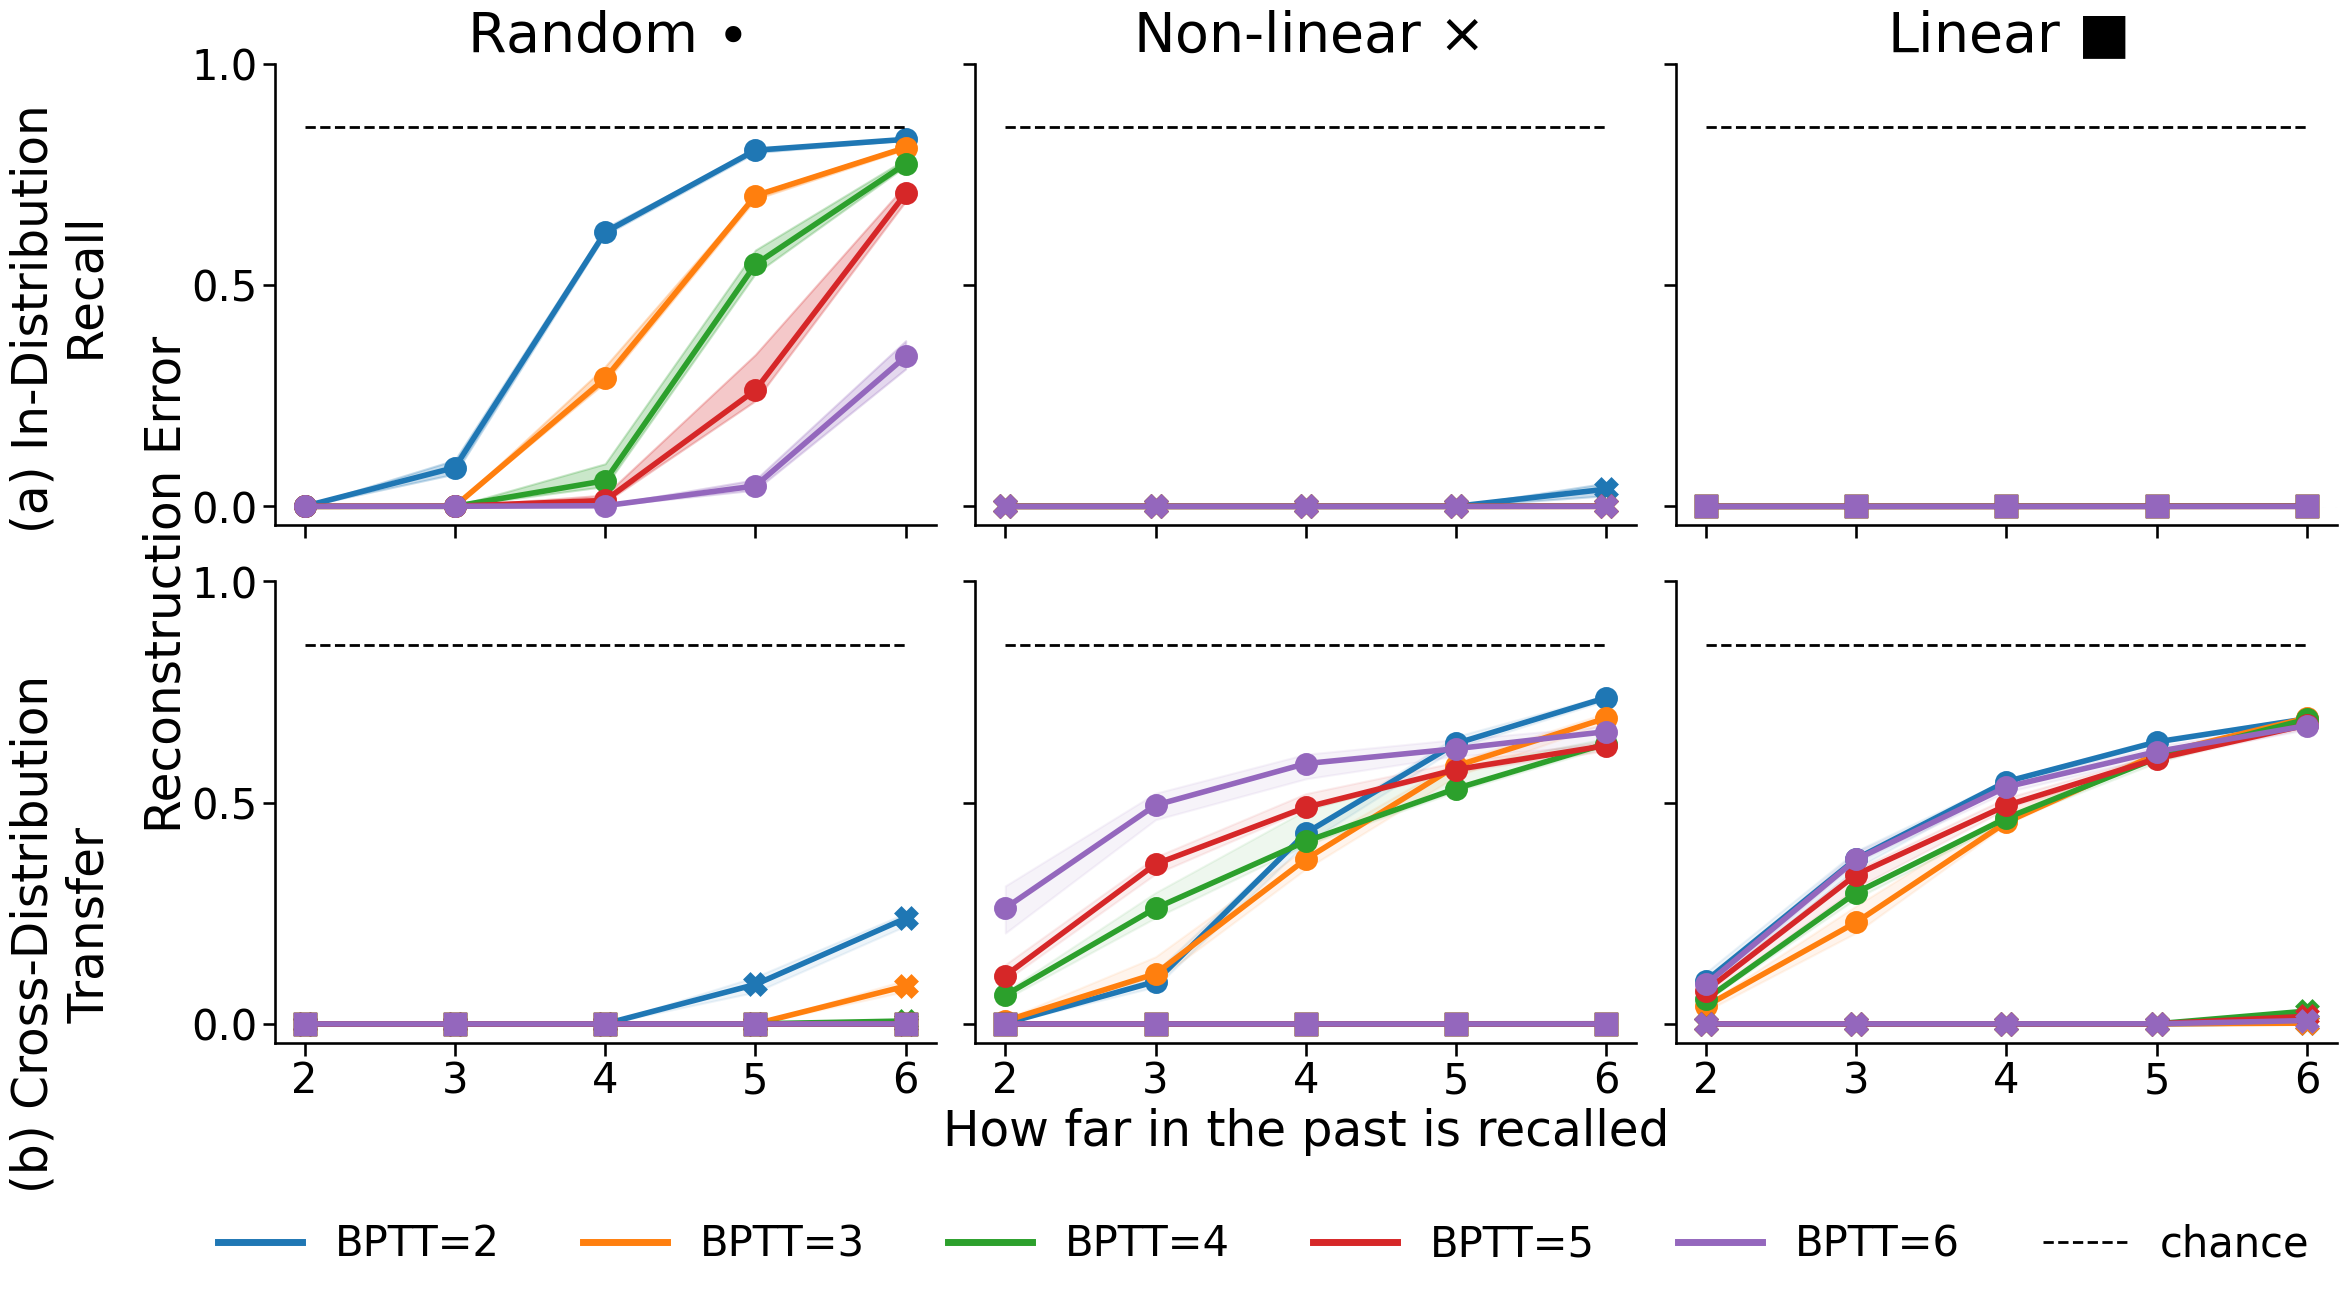

In [101]:
# ===================== LOAD =====================
with open('../pickle_files/memory_capacity_random_autoencoder.pickle', 'rb') as f:
    df_random = pickle.load(f)

with open('../pickle_files/memory_capacity_linear_autoencoder.pickle', 'rb') as f:
    df_linear = pickle.load(f)

with open('../pickle_files/memory_capacity_nonlinear_autoencoder.pickle', 'rb') as f:
    df_nonlinear = pickle.load(f)

with open('../pickle_files/memory_capacity_random_pretrained_autoencoder.pickle', 'rb') as f:
    df_random_pre = pickle.load(f)

with open('../pickle_files/memory_capacity_nonlinear_pretrained_autoencoder.pickle', 'rb') as f:
    df_nonlinear_pre = pickle.load(f)

with open('../pickle_files/memory_capacity_linear_pretrained_autoencoder.pickle', 'rb') as f:
    df_linear_pre = pickle.load(f)

# ===================== HELPERS =====================
def detect_eval_datasets(df):
    datasets = []
    for c in df.columns:
        if isinstance(c, str) and c.startswith("accuracy "):
            datasets.append(c.replace("accuracy ", "").strip())
    order = ["Random", "Nonlinear", "Linear"]
    return sorted(set(datasets), key=lambda x: order.index(x))

def collect_errors_by_dataset(df, reps, bptts, past_recalls, dataset):
    acc_col = f"accuracy {dataset}"
    rec_col = f"Recall {dataset}"

    out = {str(b): [] for b in bptts}

    for rep in range(reps):
        for bptt in bptts:
            sub = df[(df["BPTT"] == bptt) & (df["reps"] == rep)][[rec_col, acc_col]].copy()
            sub = sub.sort_values(rec_col)
            rec_to_err = {int(r): float(1.0 - a) for r, a in zip(sub[rec_col].values, sub[acc_col].values)}
            row = [rec_to_err.get(int(r), np.nan) for r in past_recalls]
            out[str(bptt)].append(row)

    for b in bptts:
        out[str(b)] = np.asarray(out[str(b)], dtype=float)
    return out

# ===================== SETTINGS =====================
sns.set_context('talk')
fontsize = 40

reps = 10
bptts = [2,3,4,5,6]
past_recalls = [2,3,4,5,6]

cmap = plt.get_cmap("tab10")
color_map = {bptt: cmap(i) for i, bptt in enumerate(bptts)}

dataset_marker = {
    "Random": "o",
    "Nonlinear": "X",
    "Linear": "s",
}

MARKER_SIZE = 14
MARKER_EDGE = 2.5

# ===================== FIGURE =====================
fig, ax = plt.subplots(2,3, figsize=(22,12), sharey=True, sharex=True)

# ===================== TOP ROW =====================
def plot_top(ax_sub, df, dataset_name):
    result = {str(b): [] for b in bptts}

    for rep in range(reps):
        for bptt in bptts:
            result[str(bptt)].append(
                list(1 - df[(df['BPTT']==bptt)&(df['reps']==rep)]['accuracy'])
            )

    for bptt in bptts:
        result[str(bptt)] = np.asarray(result[str(bptt)], dtype=float)
        col = color_map[bptt]
        mk = dataset_marker[dataset_name]

        y = np.nanmedian(result[str(bptt)], axis=0)
        y25 = np.nanquantile(result[str(bptt)], 0.25, axis=0)
        y75 = np.nanquantile(result[str(bptt)], 0.75, axis=0)

        ax_sub.plot(
            past_recalls, y,
            color=col,
            linestyle='-',
            marker=mk,
            markersize=MARKER_SIZE,
            markeredgewidth=MARKER_EDGE,
            linewidth=4
        )
        ax_sub.fill_between(past_recalls, y25, y75, color=col, alpha=0.25)

plot_top(ax[0][0], df_random, "Random")
plot_top(ax[0][1], df_nonlinear, "Nonlinear")
plot_top(ax[0][2], df_linear, "Linear")

# ===================== BOTTOM ROW =====================
def plot_bottom(ax_sub, df_pre):
    eval_datasets = detect_eval_datasets(df_pre)

    for dataset in eval_datasets:
        res = collect_errors_by_dataset(df_pre, reps, bptts, past_recalls, dataset)
        mk = dataset_marker[dataset]

        for bptt in bptts:
            col = color_map[bptt]

            y = np.nanmedian(res[str(bptt)], axis=0)
            y25 = np.nanquantile(res[str(bptt)], 0.25, axis=0)
            y75 = np.nanquantile(res[str(bptt)], 0.75, axis=0)

            ax_sub.plot(
                past_recalls, y,
                color=col,
                linestyle='-',
                marker=mk,
                markersize=MARKER_SIZE,
                markeredgewidth=MARKER_EDGE,
                linewidth=4
            )
            ax_sub.fill_between(past_recalls, y25, y75, color=col, alpha=0.08)

plot_bottom(ax[1][0], df_random_pre)
plot_bottom(ax[1][1], df_nonlinear_pre)
plot_bottom(ax[1][2], df_linear_pre)

# ===================== CHANCE LINE =====================
chance = 1 - 1/7.0
for jj in range(2):
    for ii in range(3):
        ax[jj][ii].hlines(chance, 2, 6, linestyle='--', color='black', linewidth=2)
        ax[jj][ii].spines["right"].set_visible(False)
        ax[jj][ii].spines["top"].set_visible(False)
        ax[jj][ii].set_yticks([0,.5,1])
        ax[jj][ii].tick_params(labelsize=fontsize-10)

# ===================== TITLES WITH MARKERS =====================
ax[0][0].set_title(r"Random $\bullet$", fontsize=fontsize)
ax[0][1].set_title(r"Non-linear $\times$", fontsize=fontsize)
ax[0][2].set_title(r"Linear $\blacksquare$", fontsize=fontsize)

ax[1][1].set_xlabel('How far in the past is recalled', fontsize=fontsize-5)

fig.text(-0.01,.3,'Reconstruction Error', fontsize=fontsize-5, rotation=90)
fig.text(-0.07,.55,'(a) In-Distribution\n           Recall', fontsize=fontsize-5, rotation=90)
fig.text(-0.07,.0,'(b) Cross-Distribution\n           Transfer', fontsize=fontsize-5, rotation=90)

# ===================== GLOBAL BPTT LEGEND (COLORS ONLY) =====================
bptt_handles = []
bptt_labels = []
for bptt in bptts:
    bptt_handles.append(
        plt.Line2D([0],[0], color=color_map[bptt], linewidth=5)
    )
    bptt_labels.append(f'BPTT={bptt}')

chance_handle = plt.Line2D([0],[0], color='black', linestyle='--', linewidth=2)

fig.legend(
    bptt_handles + [chance_handle],
    bptt_labels + ['chance'],
    bbox_to_anchor=(.5, -0.1),
    loc="lower center",
    ncol=6,
    fontsize=30,
    frameon=False
)


plt.tight_layout()
plt.savefig('../plots/memory_capacity_RNN_autoencoder.pdf', bbox_inches='tight')

plt.show()
